# Phase II: Data Collection and Exploratory Data Analysis

**Research Question(s):**
- Main question: How does distance, passenger volume, and carrier type affect average airfare prices in U.S. nonstop flight markets?
- Secondary questions:
   - How does airfare change as flight distance increases? Are shorter flights more expensive per mile than longer ones?
   - Is there a relationship between passenger count and average fare (for example, do more popular routes tend to have lower fares due to competition)?

## Data Source
- US Airline Flight Routes and Fares 1993–2024, provided by the Bureau of Transportation Statistics (BTS).  
- Available on Kaggle: [US Airline Flight Routes and Fares Dataset](https://www.kaggle.com/datasets/bhavikjikadara/us-airline-flight-routes-and-fares-1993-2024)

**Why this dataset?**
- It provides detailed fare and passenger data for thousands of U.S. flight routes over time, allowing us to explore how distance, competition, and market structure influence airfare pricing.

In [30]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt


# Date Cleaning

#### How We Loaded in Our Dataset
**Map** 
We created a map for the expected data types 


In [9]:
dtype_map = {
    "tbl": "object",
    "Year": "int64",
    "quarter": "int64",
    "citymarketid_1": "int64",
    "citymarketid_2": "int64",
    "city1": "object",
    "city2": "object",
    "airportid_1": "int64",
    "airportid_2": "int64",
    "airport_1": "object",
    "airport_2": "object",
    "nsmiles": "int64",
    "passengers": "int64",
    "fare": "float64",
    "carrier_lg": "object",
    "large_ms": "float64",
    "fare_lg": "float64",
    "carrier_low": "object",
    "fare_low": "float64",
    "Geocoded_City1": "object",
    "Geocoded_City2": "object",
    "tbl1apk": "object"
}
flight_df = pd.read_csv('US Airline Flight Routes and Fares 1993-2024.csv', dtype=dtype_map)

flight_df.info()
flight_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  object 
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  object 
 6   city2           245955 non-null  object 
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  object 
 10  airport_2       245955 non-null  object 
 11  nsmiles         245955 non-null  int64  
 12  passengers      245955 non-null  int64  
 13  fare            245955 non-null  float64
 14  carrier_lg      244415 non-null  object 
 15  large_ms        244415 non-null  float64
 16  fare_lg         244415 non-null  float64
 17  carrier_lo

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


**Dropping Unnecessary Columns**\
Within this dataset, several columns contain identifiers or redundant information that are not relevant to our analysis. Since our research focuses on how distance, passenger volume, and carrier type affect airfare, we will remove columns that do not contribute to those variables.

We are dropping:
- tbl: table label not needed for analysis
- citymarketid_1, citymarketid_2: internal market identifiers
- airportid_1, airportid_2: duplicate information since we are keeping airport codes instead
- Geocoded_City1, Geocoded_City2: geocoded fields with redundant data

These columns do not give insight into airfare patterns and will be removed to simplify the dataset.


In [10]:
flight_df = flight_df.drop(['tbl', 'airportid_1', 'airportid_2', 'citymarketid_1', 'citymarketid_2', 'Geocoded_City1', 'Geocoded_City2', ], axis=1)
flight_df.head()

,Year,quarter,city1,city2,airport_1,airport_2,nsmiles,passengers,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,tbl1apk
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",ABE,PIE,970,180,81.43,G4,1.0000,81.43,G4,1.0000,81.43,202131013514112ABEPIE
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",ABE,TPA,970,19,208.93,DL,0.4659,219.98,UA,0.1193,154.11,202131013515304ABETPA
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",ABQ,DAL,580,204,184.56,WN,0.9968,184.44,WN,0.9968,184.44,202131014011259ABQDAL
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",ABQ,DFW,580,264,182.64,AA,0.9774,183.09,AA,0.9774,183.09,202131014011298ABQDFW
4,2021,3,"Albuquerque, NM","Phoenix, AZ",ABQ,PHX,328,398,177.11,WN,0.6061,184.49,AA,0.3939,165.77,202131014014107ABQPHX


**Find Missing Values**\
While we know that missing values can be handled by a NaN value, it is always better to not have them. These missing values can cause errors in our statistical analysis, especially in a machine learning model

In [11]:
missing_values_per_column = flight_df.isnull().sum()
print(missing_values_per_column)

Year              0
quarter           0
city1             0
city2             0
airport_1         0
airport_2         0
nsmiles           0
passengers        0
fare              0
carrier_lg     1540
large_ms       1540
fare_lg        1540
carrier_low    1612
lf_ms          1612
fare_low       1612
tbl1apk           0
dtype: int64


In [12]:
distance_trends = flight_df.groupby("nsmiles")["fare"].mean().reset_index()
distance_trends.head()

,nsmiles,fare
0,109,138.626667
1,115,125.338750
2,122,95.719512
3,129,111.930000
4,130,164.855373


**graphing fare vs quarter**\
With this data set we want to look at how certain quarters with many holidays (such as quarter one and four) have differing airline fare prices when compared to those without many holidays. We grouped by quarters in order to allow us to access the average fare per quarter for every year and average them. 

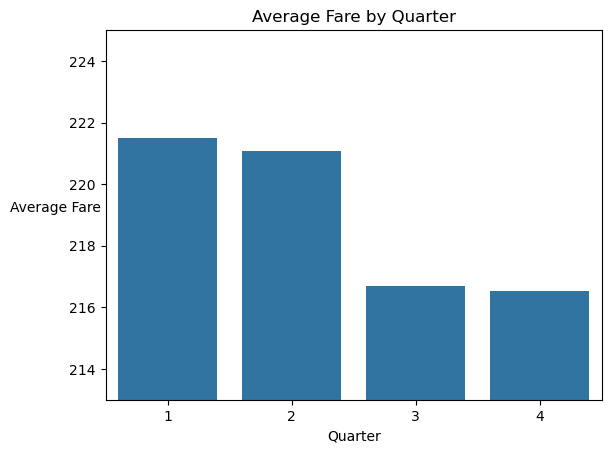

In [44]:
fare_quarter_df = duckdb.sql("""SELECT AVG(fare) AS average_fare, quarter FROM flight_df GROUP BY quarter""").df()
sns.barplot(data = fare_quarter_df, x = "quarter", y = "average_fare")
plt.ylim(213, 225)

plt.title("Average Fare by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Fare", rotation = 0,labelpad = 10);

**Findings**\
This graph demonstrates that airlines increase the prices for flights during the start of the year (the first and second quarters). This is vastly different than what we expected since we predicted that the fourth quarter would have the highest fares. This is very unexpected for us since we figured holidays like christmas, thanksgiving and new years would increase travel rates and fares. The data clearly does not support this claim since the first half of the year has the most costly airline tickets. 